Fetching NLCD data from USGS...


/opt/anaconda3/envs/ISAT_420/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  ds = xr.merge(
/opt/anaconda3/envs/ISAT_420/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  ds = xr.merge(
/opt/anaconda3/envs/ISAT_420/lib/python3.13/site-packages/pygeoutils/pygeo

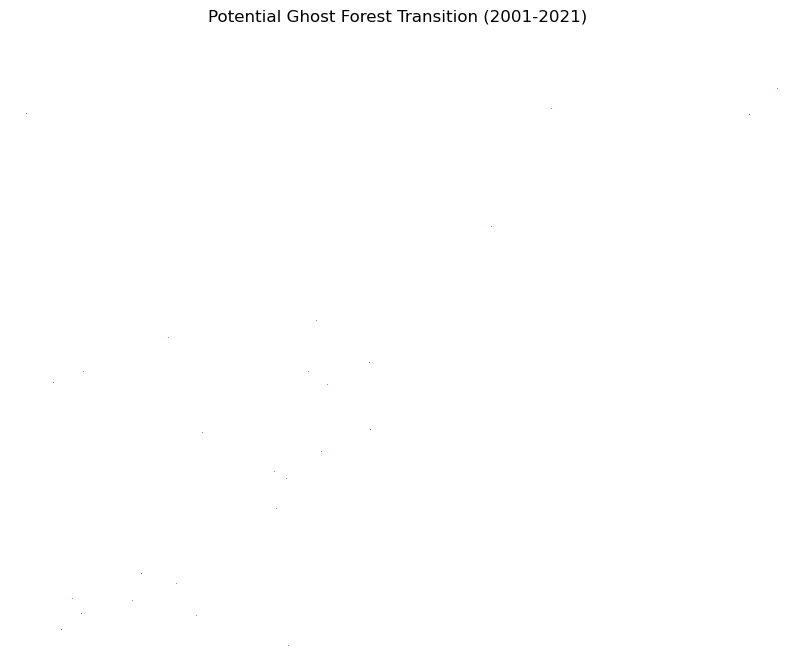

Number of 30m pixels identified as ghost forest transition: 4915.0


In [21]:
import pygeohydro as gh
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import numpy as np

# 1. Define your area (minx, miny, maxx, maxy)
bbox = [-77.5, 36.5, -75.0, 40.0]

# 2. Convert the bounding box into a GeoDataFrame
# We define the CRS as 4326 (standard Latitude/Longitude)
geometry = gpd.GeoDataFrame({'geometry': [box(*bbox)]}, crs="EPSG:4326")

# 3. Fetch NLCD data using nlcd_bygeom
# You must provide the resolution (in meters) and the years in a dictionary
# The result is a dictionary, so we access it with the key 0
print("Fetching NLCD data from USGS...")
nlcd_dict = gh.nlcd_bygeom(geometry, resolution=30, years={'cover': [2001, 2021]})
nlcd = nlcd_dict[0] # The 0 index corresponds to your geometry

# 4. Separate the years
# The returned object will have 'cover_2001' and 'cover_2021' variables
ds2001 = nlcd['cover_2001']
ds2021 = nlcd['cover_2021']

# 5. Define classes and analyze
was_forest = ds2001.isin([41, 42, 43])
is_wetland = ds2021.isin([90, 95])

ghost_forest_mask = was_forest & is_wetland

# 6. Apply mask and plot
transition_map = ghost_forest_mask.where(ghost_forest_mask == True, np.nan).astype(float)

plt.figure(figsize=(10, 8))
transition_map.plot(cmap='Reds', add_colorbar=False)
plt.title('Potential Ghost Forest Transition (2001-2021)')
plt.axis('off')
plt.show()

# 7. Statistical Check
count = np.nansum(transition_map.values)
print(f"Number of 30m pixels identified as ghost forest transition: {count}")

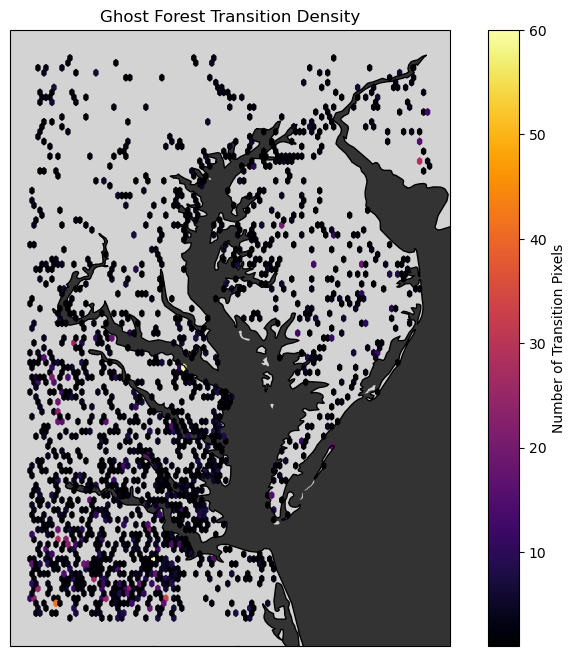

In [22]:
# 1. Stack the dimensions 'x' and 'y' into one dimension called 'pixel'
# 2. Drop all the NaNs (so we only keep the 'True' / 1.0 pixels)
valid_pixels = transition_map.stack(pixel=('x', 'y')).dropna('pixel')

# 3. Now extract the X and Y coordinates from the valid pixels
lons = valid_pixels.x.values
lats = valid_pixels.y.values

# 4. Now plot
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE)

# Now these arrays are guaranteed to be the same length
hb = ax.hexbin(lons, lats, gridsize=100, cmap='inferno', mincnt=1, transform=ccrs.PlateCarree())

plt.colorbar(hb, label='Number of Transition Pixels')
plt.title('Ghost Forest Transition Density')
plt.show()

In [1]:
import py3dep
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 1. Fetch the DEM (You already have the 'geometry' object from your previous cell)
# The order is: (minx, miny, maxx, maxy)
bbox = [-77.5, 36.5, -75.0, 40.0]

# 2. Pass the bbox list directly to get_dem
print("Fetching DEM from USGS 3DEP...")
dem = py3dep.get_dem(bbox, resolution=100) 

# Continue with the rest of your code
dem_aligned = dem.interp_like(transition_map, method='nearest')

# 3. Apply the Elevation Threshold
# This replaces the need for "buffering"
# Pixels are kept ONLY if they are:
#   A) A transition (Ghost Forest) AND
#   B) Below the elevation threshold (e.g., 2.0 meters)
elevation_threshold = 2.0 
is_low_elevation = dem_aligned < elevation_threshold

# 4. Combine the masks
# This is a boolean operation (True & True = True)
final_ghost_forest = ghost_forest_mask & is_low_elevation

# 5. Plot the result
plt.figure(figsize=(10, 8))
# We use .where(mask) to turn all 'False' pixels into NaNs so they disappear on the plot
final_ghost_forest.where(final_ghost_forest == True).plot(cmap='Reds', add_colorbar=False)
plt.title('Ghost Forest Transition (Elevation Filtered < 2m)')
plt.axis('off')
plt.show()

# 6. Statistical Check
count = np.nansum(final_ghost_forest.values)
print(f"Number of valid ghost forest pixels after DEM filtering: {count}")

Fetching DEM from USGS 3DEP...


ServiceUnavailableError: Service is currently not available, try again later:
https://elevation.nationalmap.gov/arcgis/services/3DEPElevation/ImageServer/WMSServer